In [4]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv("cardekho_dataset.csv")

# View first 5 rows
df.head()

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [7]:
df.shape

(15411, 14)

In [8]:
df.columns

Index(['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven',
       'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine',
       'max_power', 'seats', 'selling_price'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         15411 non-null  int64  
 1   car_name           15411 non-null  object 
 2   brand              15411 non-null  object 
 3   model              15411 non-null  object 
 4   vehicle_age        15411 non-null  int64  
 5   km_driven          15411 non-null  int64  
 6   seller_type        15411 non-null  object 
 7   fuel_type          15411 non-null  object 
 8   transmission_type  15411 non-null  object 
 9   mileage            15411 non-null  float64
 10  engine             15411 non-null  int64  
 11  max_power          15411 non-null  float64
 12  seats              15411 non-null  int64  
 13  selling_price      15411 non-null  int64  
dtypes: float64(2), int64(6), object(6)
memory usage: 1.6+ MB


In [10]:
df.describe()

,Unnamed: 0,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price
count,15411.000000,15411.000000,1.541100e+04,15411.000000,15411.000000,15411.000000,15411.000000,1.541100e+04
mean,9811.857699,6.036338,5.561648e+04,19.701151,1486.057751,100.588254,5.325482,7.749711e+05
std,5643.418542,3.013291,5.161855e+04,4.171265,521.106696,42.972979,0.807628,8.941284e+05
min,0.000000,0.000000,1.000000e+02,4.000000,793.000000,38.400000,0.000000,4.000000e+04
25%,4906.500000,4.000000,3.000000e+04,17.000000,1197.000000,74.000000,5.000000,3.850000e+05
50%,9872.000000,6.000000,5.000000e+04,19.670000,1248.000000,88.500000,5.000000,5.560000e+05
75%,14668.500000,8.000000,7.000000e+04,22.700000,1582.000000,117.300000,5.000000,8.250000e+05
max,19543.000000,29.000000,3.800000e+06,33.540000,6592.000000,626.000000,9.000000,3.950000e+07


In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [12]:
df.isnull().sum()

car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [13]:
# Fill numerical columns with median
df['mileage'].fillna(df['mileage'].mode()[0], inplace=True)
df['engine'].fillna(df['engine'].mode()[0], inplace=True)
df['max_power'].fillna(df['max_power'].mode()[0], inplace=True)

# Drop remaining missing rows
df.dropna(inplace=True)

In [14]:
df['mileage'] = df['mileage'].astype(str)
df['mileage'] = df['mileage'].str.extract('(\d+\.?\d*)')
df['mileage'] = df['mileage'].astype(float)

In [15]:
df['engine'] = df['engine'].astype(str)
df['engine'] = df['engine'].str.extract('(\d+)')
df['engine'] = df['engine'].astype(float)

In [16]:
df['max_power'] = df['max_power'].astype(str)
df['max_power'] = df['max_power'].str.extract('(\d+\.?\d*)')
df['max_power'] = df['max_power'].astype(float)

In [17]:
df[['mileage','engine','max_power']].head()

,mileage,engine,max_power
0,19.70,796.0,46.30
1,18.90,1197.0,82.00
2,17.00,1197.0,80.00
3,20.92,998.0,67.10
4,22.77,1498.0,98.59


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15411 entries, 0 to 15410
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   car_name           15411 non-null  object 
 1   brand              15411 non-null  object 
 2   model              15411 non-null  object 
 3   vehicle_age        15411 non-null  int64  
 4   km_driven          15411 non-null  int64  
 5   seller_type        15411 non-null  object 
 6   fuel_type          15411 non-null  object 
 7   transmission_type  15411 non-null  object 
 8   mileage            15411 non-null  float64
 9   engine             15411 non-null  float64
 10  max_power          15411 non-null  float64
 11  seats              15411 non-null  int64  
 12  selling_price      15411 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 1.5+ MB


In [19]:
df['price_lakh'] = df['selling_price'] / 100000

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df = df[df['selling_price'] < df['selling_price'].quantile(0.99)]

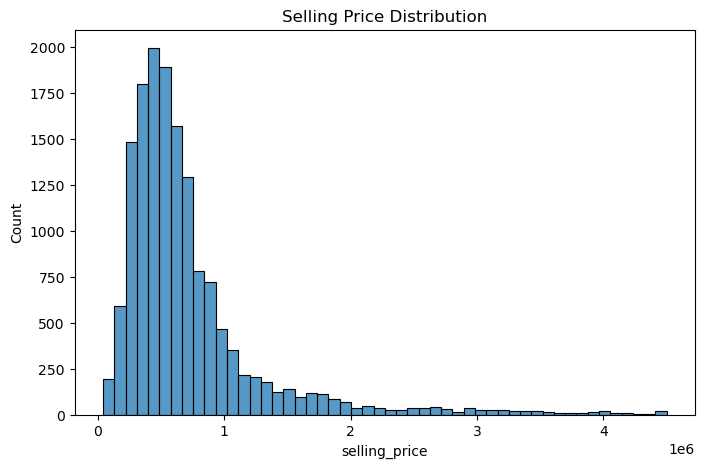

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['selling_price'], bins=50)
plt.title("Selling Price Distribution")
plt.show()

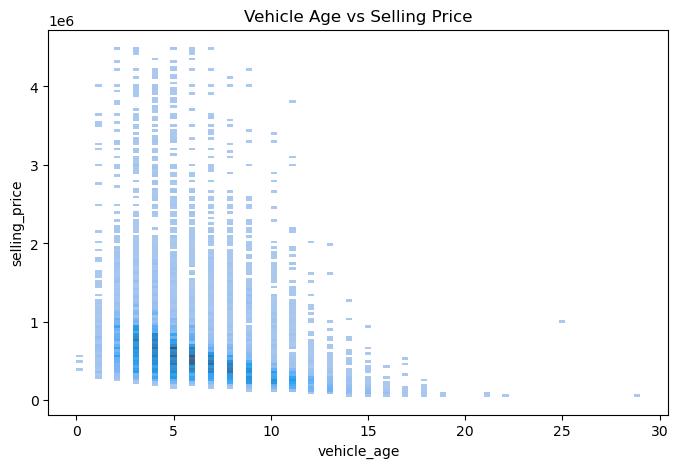

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(x='vehicle_age', y='selling_price', data=df)
plt.title("Vehicle Age vs Selling Price")
plt.show()

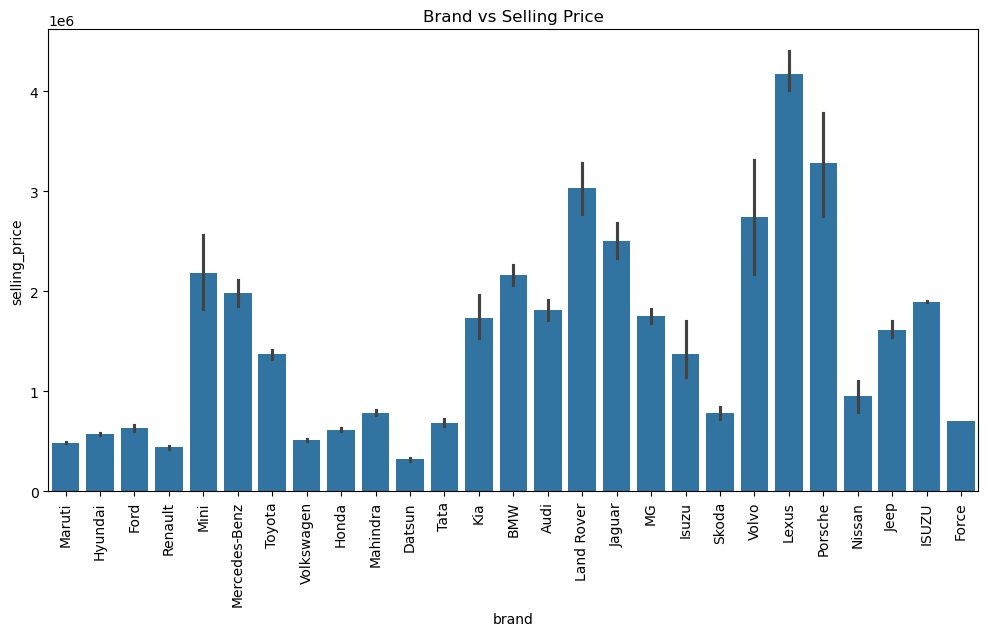

In [25]:
plt.figure(figsize=(12,6))
sns.barplot(x='brand', y='selling_price', data=df)
plt.xticks(rotation=90)
plt.title("Brand vs Selling Price")
plt.show()

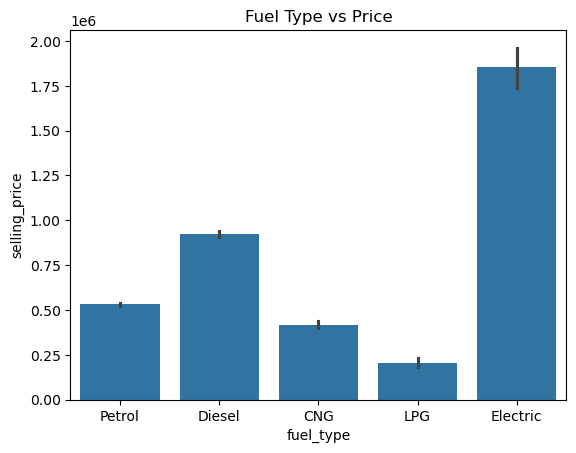

In [26]:
sns.barplot(x='fuel_type', y='selling_price', data=df)
plt.title("Fuel Type vs Price")
plt.show()

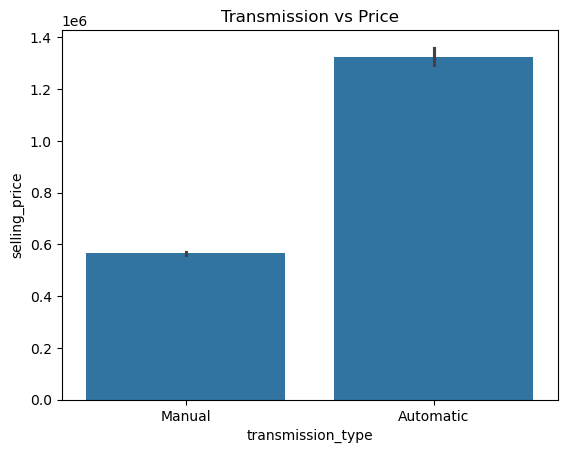

In [27]:
sns.barplot(x='transmission_type', y='selling_price', data=df)
plt.title("Transmission vs Price")
plt.show()

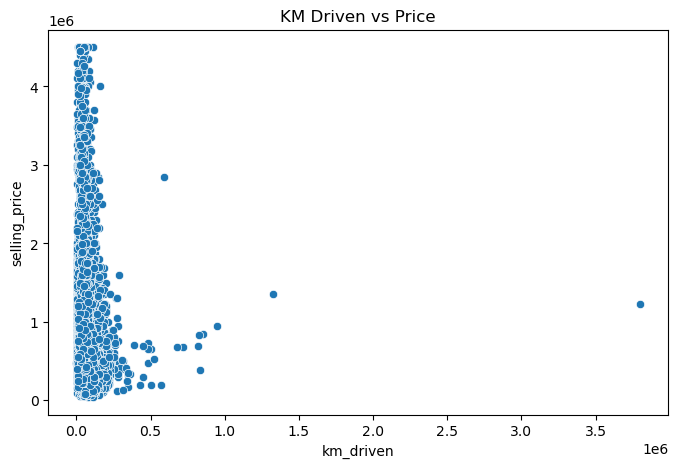

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='km_driven', y='selling_price', data=df)
plt.title("KM Driven vs Price")
plt.show()

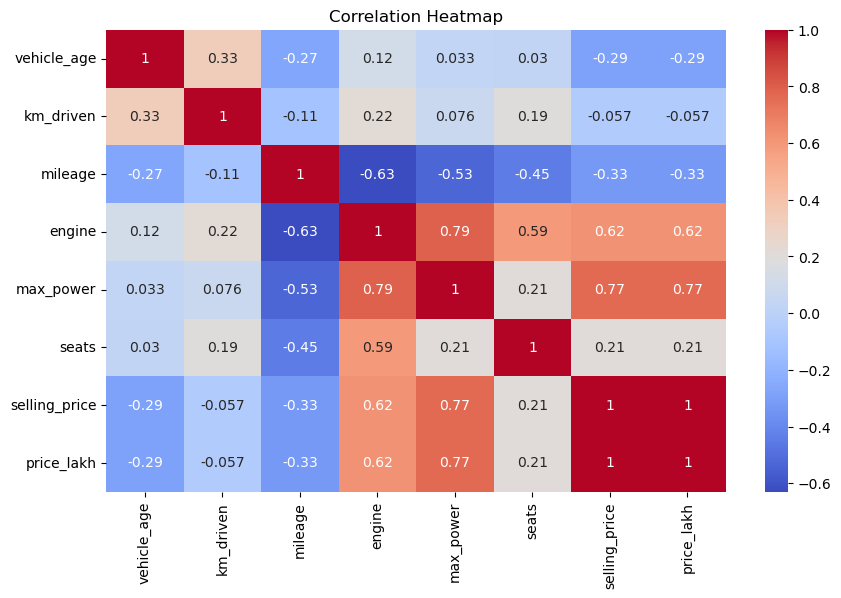

In [29]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [30]:
df.to_csv("cleaned_car_data.csv", index=False)

In [33]:
import os
os.getcwd()

'C:\\Users\\SOUMYAJIT'

In [34]:
df.to_csv(r"D:\DA project\cleaned_car_data.csv", index=False)

In [35]:
!pip install psycopg2-binary sqlalchemy

In [36]:
import pandas as pd
from sqlalchemy import create_engine

In [37]:
username = "postgres"
password = "sk123"
host = "localhost"
port = "5432"
database = "car_analysis_db"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

In [38]:
df = pd.read_csv("cleaned_car_data.csv")
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price,price_lakh
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796.0,46.30,5,120000,1.20
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197.0,82.00,5,550000,5.50
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197.0,80.00,5,215000,2.15
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998.0,67.10,5,226000,2.26
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498.0,98.59,5,570000,5.70


In [39]:
df.to_sql("cars", engine, if_exists="replace", index=False)

91